# FINESST TOI-270 d retrieval comparison

This notebook creates the publication-quality three-part comparison of the completed POSEIDON/PyMultiNest and POSEIDON-NPSE retrievals. It reads saved products only and does **not** rerun either retrieval or evaluate the atmospheric forward model.

## Important provenance note

The selected products retrieve the same 13 named parameters from the same 179 TOI-270 d data points. The PyMultiNest run used CLR abundance priors and $R=30{,}000$, while NPSE used independent uniform log-abundance priors and $R=20{,}000$. The JSON metadata records this distinction, so these outputs should not be presented as a controlled sampler-only test.

In [1]:
#***** Imports and portable path setup *****#

from pathlib import Path
import sys
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
RUN_DIR = None
for candidate in [cwd, *cwd.parents]:
    if candidate.name == 'run' and (candidate / 'FINESST_Retrieval_Comparison_Plot.py').is_file():
        RUN_DIR = candidate
        break
    if (candidate / 'run' / 'FINESST_Retrieval_Comparison_Plot.py').is_file():
        RUN_DIR = candidate / 'run'
        break

if RUN_DIR is None:
    # try the current working directory first (useful when running inside the FINESST/ folder)
    if (cwd / 'FINESST_Retrieval_Comparison_Plot.py').is_file():
        RUN_DIR = cwd
    else:
        # as a last resort, search recursively under cwd for the file
        matches = list(cwd.rglob('FINESST_Retrieval_Comparison_Plot.py'))
        if matches:
            RUN_DIR = matches[0].parent
        else:
            raise FileNotFoundError('Could not locate POSEIDON/run/FINESST_Retrieval_Comparison_Plot.py')
if str(RUN_DIR) not in sys.path:
    sys.path.insert(0, str(RUN_DIR))

from FINESST_Retrieval_Comparison_Plot import (
    default_config,
    load_products,
    make_comparison_figure,
    save_comparison_figure,
)

config = default_config(RUN_DIR)
print('Using run directory:', RUN_DIR)

Using run directory: /home/eraul/wisconsin/work/atmosphere_research_2026/POSEIDON/run/FINESST


## Retrieval names and colors

In [2]:
#***** Retrieval names and color-blind-safe palette *****#

PMN_LABEL = 'PyMultiNest'
SBI_LABEL = 'SBI'
PMN_COLOR = '#E3770B'
SBI_COLOR = "#0B1DE3"
OBSERVED_DATA_COLOR = '#262626'
PROJECTED_REGION_COLOR = "#605D5D"

config.pmn_label = PMN_LABEL
config.sbi_label = SBI_LABEL
config.style.pmn_color = PMN_COLOR
config.style.sbi_color = SBI_COLOR
config.style.data_color = OBSERVED_DATA_COLOR
config.style.projected_region_color = PROJECTED_REGION_COLOR

## Overall figure size and panel spacing

FIGURE_WIDTH_INCHES and FIGURE_HEIGHT_INCHES control physical dimensions. POSTERIOR_PANEL_HORIZONTAL_SPACE controls the small-panel spacing, while TOP_PANEL_EXTRA_HORIZONTAL_SPACE independently widens only the gap between Panels (a) and (b). VERTICAL_PANEL_SPACE controls vertical GridSpec spacing.

In [3]:
#***** Global dimensions, margins, and inter-panel spacing *****#

FIGURE_WIDTH_INCHES = 11.0
FIGURE_HEIGHT_INCHES = 6.6
POSTERIOR_PANEL_HORIZONTAL_SPACE = 0.92
TOP_PANEL_EXTRA_HORIZONTAL_SPACE = 0.02875  # fraction of total figure width
VERTICAL_PANEL_SPACE = 0.62

FIGURE_LEFT_MARGIN = 0.015
FIGURE_RIGHT_MARGIN = 0.985
FIGURE_BOTTOM_MARGIN = 0.015
FIGURE_TOP_MARGIN = 0.985

AUTO_SIZE_POSTERIOR_GRID = True
POSTERIOR_COLUMNS = 6
TOP_PANEL_WIDTH_FRACTION = 0.60
TOP_ROW_HEIGHT = 1.15
VALIDATION_ROW_HEIGHT = 0.01
POSTERIOR_ROW_HEIGHT = 1.12

config.layout.figure_kwargs.update(figsize=(FIGURE_WIDTH_INCHES, FIGURE_HEIGHT_INCHES), constrained_layout=False)
config.layout.subplot_mosaic_kwargs['gridspec_kw'].update(wspace=POSTERIOR_PANEL_HORIZONTAL_SPACE, hspace=VERTICAL_PANEL_SPACE)
config.layout.subplots_adjust_kwargs.update(left=FIGURE_LEFT_MARGIN, right=FIGURE_RIGHT_MARGIN, bottom=FIGURE_BOTTOM_MARGIN, top=FIGURE_TOP_MARGIN)
config.layout.auto_posterior_layout = AUTO_SIZE_POSTERIOR_GRID
config.layout.posterior_columns = POSTERIOR_COLUMNS
config.layout.top_width_fraction = TOP_PANEL_WIDTH_FRACTION
config.layout.top_row_height = TOP_ROW_HEIGHT
config.layout.metrics_row_height = VALIDATION_ROW_HEIGHT
config.layout.posterior_row_height = POSTERIOR_ROW_HEIGHT
config.layout.top_panel_extra_horizontal_space = TOP_PANEL_EXTRA_HORIZONTAL_SPACE

# For a fully custom mosaic, set AUTO_SIZE_POSTERIOR_GRID=False and then set:
# config.layout.mosaic = '''
#     AAAAABBB
#     AAAAABBB
#     MMMMMMMM
#     ccddeeff
#     gghhiijj
# '''
# config.layout.posterior_axis_keys = tuple('cdefghij')

## Typography, ticks, and axis boxes

POSEIDON's standard plotting style uses classic serif typography. Set USE_SANS_SERIF=True for its sans-serif/fancy-style alternative.

In [4]:
#***** POSEIDON-style typography and axes *****#

USE_SANS_SERIF = False
SERIF_FONT = 'DejaVu Serif'
SANS_SERIF_FONT = 'DejaVu Sans'
AXIS_LABEL_FONTSIZE = 16
TICK_LABEL_FONTSIZE = 11
LEGEND_FONTSIZE = 12.0
ANNOTATION_FONTSIZE = 8.5
PANEL_LABEL_FONTSIZE = 13.0
AXIS_BOX_LINE_WIDTH = 0.8
MAJOR_TICK_LENGTH = 4.0
MINOR_TICK_LENGTH = 2.2

config.style.use_sans_serif = USE_SANS_SERIF
config.style.serif_font = SERIF_FONT
config.style.sans_serif_font = SANS_SERIF_FONT
config.style.axis_label_size = AXIS_LABEL_FONTSIZE
config.runtime.x_label_size = AXIS_LABEL_FONTSIZE
config.runtime.y_label_size = AXIS_LABEL_FONTSIZE
config.style.tick_label_size = TICK_LABEL_FONTSIZE
config.style.legend_size = LEGEND_FONTSIZE
config.style.annotation_size = ANNOTATION_FONTSIZE
config.style.panel_label_size = PANEL_LABEL_FONTSIZE
config.style.tick_width = AXIS_BOX_LINE_WIDTH
config.style.tick_length = MAJOR_TICK_LENGTH
config.style.minor_tick_length = MINOR_TICK_LENGTH

## Panel (a): observed and retrieved spectra

In [5]:
#***** Panel (a) spectrum controls *****#

SPECTRUM_R_TO_BIN = 500
PMN_SIGMA_BAND_OPACITY = 0.5
SBI_SIGMA_BAND_OPACITY = 0.5
PMN_SIGMA_BAND_ZORDER = 3
SBI_SIGMA_BAND_ZORDER = 1
PMN_SPECTRUM_LINE_ZORDER = 4
SBI_SPECTRUM_LINE_ZORDER = 5
SPECTRUM_LINE_WIDTH = 0.95
PMN_SPECTRUM_LINESTYLE = '-'
SBI_SPECTRUM_LINESTYLE = '--'
OBSERVED_MARKER_SIZE = 3.5
OBSERVED_ERRORBAR_LINE_WIDTH = 0.9
SHOW_OBSERVED_BIN_WIDTHS = False
OBSERVATION_LEGEND_LABELS = ('NIRISS SOSS', 'NIRISS SOSS', 'NIRSpec G395H', 'NIRSpec G395H')
OBSERVATION_MARKERS = ('o', 'o', 'D', 'D')  # NIRISS circles, NIRSpec diamonds
DATA_N_WAVELENGTH_BINS = 100  # no binning; set to 50 for up to 50 wavelength bins
SPECTRUM_LEGEND_LOCATION = 'upper right'
SPECTRUM_LEGEND_COLUMNS = 2
PANEL_A_X_AXIS_LABEL = r'Wavelength ($\mu$m)'
PANEL_A_Y_AXIS_LABEL = 'Transit Depth (ppm)'
SPECTRUM_X_LIMITS = (0.58, 5.30)
SPECTRUM_Y_LIMITS = None

config.spectrum.R_to_bin = SPECTRUM_R_TO_BIN
config.spectrum.pmn_band_kwargs.update(alpha=PMN_SIGMA_BAND_OPACITY, zorder=PMN_SIGMA_BAND_ZORDER)
config.spectrum.sbi_band_kwargs.pop('hatch', None)
config.spectrum.sbi_band_kwargs.update(alpha=SBI_SIGMA_BAND_OPACITY, zorder=SBI_SIGMA_BAND_ZORDER)
config.spectrum.pmn_line_kwargs.update(linewidth=SPECTRUM_LINE_WIDTH, linestyle=PMN_SPECTRUM_LINESTYLE, zorder=PMN_SPECTRUM_LINE_ZORDER)
config.spectrum.sbi_line_kwargs.update(linewidth=SPECTRUM_LINE_WIDTH, linestyle=SBI_SPECTRUM_LINESTYLE, zorder=SBI_SPECTRUM_LINE_ZORDER)
config.spectrum.data_errorbar_kwargs.update(markersize=OBSERVED_MARKER_SIZE)
config.style.errorbar_line_width = OBSERVED_ERRORBAR_LINE_WIDTH
config.spectrum.show_data_bin_width = SHOW_OBSERVED_BIN_WIDTHS
config.spectrum.observation_labels = OBSERVATION_LEGEND_LABELS
config.spectrum.observation_markers = OBSERVATION_MARKERS
config.spectrum.data_n_wavelength_bins = DATA_N_WAVELENGTH_BINS
config.spectrum.legend_kwargs.update(loc=SPECTRUM_LEGEND_LOCATION, ncol=SPECTRUM_LEGEND_COLUMNS, frameon=False)
config.spectrum.x_label = PANEL_A_X_AXIS_LABEL
config.spectrum.y_label = PANEL_A_Y_AXIS_LABEL
config.spectrum.x_limits = SPECTRUM_X_LIMITS
config.spectrum.y_limits = SPECTRUM_Y_LIMITS

## Panel (b): runtime scaling

The benchmark and regime-label positions use axes-fraction coordinates: (0, 0) is the lower-left and (1, 1) is the upper-right of Panel (b). The speedup arrow and its label use runtime data coordinates.

In [6]:
#***** Panel (b) runtime controls *****#

MEASURED_MAX_PARAMETERS = 13
BENCHMARK_PARAMETER_COUNT = 13
SHOW_RUNTIME_MARKERS = True
RUNTIME_MARKER_SIZE = 2.75
RUNTIME_LINE_WIDTH = 1.7
MEASURED_MARKER = 'o'
PROJECTED_MARKER = ''
MEASURED_LINESTYLE = '-'
PROJECTED_LINESTYLE = '--'
PANEL_B_X_AXIS_LABEL = 'Number of Free Parameters'
PANEL_B_Y_AXIS_LABEL = 'Log Total Runtime (log hr)'
RUNTIME_X_MAJOR_TICK_INTERVAL = 2
SHOW_RUNTIME_X_MINOR_TICKS = True
RUNTIME_X_MINOR_TICK_SUBDIVISIONS = 2

SHOW_BENCHMARK_ANNOTATION = True
TOI270D_ANNOTATION_TEXT = 'TOI-270 d model'
BENCHMARK_ANNOTATION_POSITION = (0.615, 0.85)
BENCHMARK_ANNOTATION_FONTSIZE = 10.0
BENCHMARK_ANNOTATION_HORIZONTAL_ALIGNMENT = 'right'
BENCHMARK_ANNOTATION_VERTICAL_ALIGNMENT = 'top'

# One-week marker: x positions and tick width are fractions of the Panel (b) width.
SHOW_ONE_WEEK_ANNOTATION = True
ONE_WEEK_HOURS = 168.0
ONE_WEEK_ANNOTATION_TEXT = '1 week'
ONE_WEEK_ANNOTATION_X = 0.035
ONE_WEEK_TICK_WIDTH = 0.025
ONE_WEEK_ANNOTATION_FONTSIZE = 8.5

# Benchmark arrow and second annotation: all positions are (parameters, hours).
SHOW_SPEEDUP_ARROW = True
SPEEDUP_ARROW_X = 12.75
SPEEDUP_ARROW_START_HOURS = 20
SPEEDUP_ARROW_END_HOURS = 3.5
SPEEDUP_ARROW_LINEWIDTH = 0.9
SHOW_SPEEDUP_ANNOTATION = True
SPEEDUP_ANNOTATION_TEXT = r'$\bf{\sim9x}$' + "\n" + r'$\bf{faster}$'
SPEEDUP_ANNOTATION_POSITION = (13.15, 12)
SPEEDUP_ANNOTATION_FONTSIZE = 10
SPEEDUP_ANNOTATION_HORIZONTAL_ALIGNMENT = 'left'
SPEEDUP_ANNOTATION_VERTICAL_ALIGNMENT = 'center'
SHOW_MEASURED_PROJECTED_LABELS = True
MEASURED_ANNOTATION_TEXT = 'Measured'
PROJECTED_ANNOTATION_TEXT = 'Projected\n(e.g., w/ Photochem)'
MEASURED_ANNOTATION_HORIZONTAL_ALIGNMENT = 'left'
PROJECTED_ANNOTATION_HORIZONTAL_ALIGNMENT = 'center'
PROJECTED_ANNOTATION_MULTIALIGNMENT = 'center'
MEASURED_LABEL_POSITION = (0.375, 0.065)
PROJECTED_LABEL_POSITION = (0.8125, 0.0675)
REGIME_ANNOTATION_FONTSIZE = 9.375
RUNTIME_LEGEND_LOCATION = 'center left'
RUNTIME_LEGEND_ANCHOR = (0.01, 0.61)
SHOW_REGIMES_IN_LEGEND = False
PROJECTED_GRAY_BELOW_SBI_OPACITY = 0.25
PROJECTED_BETWEEN_CURVES_HATCH = '//'
PROJECTED_BETWEEN_CURVES_HATCH_OPACITY = 0.75
FILL_RUNTIME_SHADING_FULL_X_RANGE = True
SHOW_RUNTIME_GRID = True
RUNTIME_X_LIMITS = (0.5, 20.5)
RUNTIME_Y_LIMITS = None

config.runtime.measured_max_parameters = MEASURED_MAX_PARAMETERS
config.runtime.benchmark_parameter_count = BENCHMARK_PARAMETER_COUNT
config.runtime.show_markers = SHOW_RUNTIME_MARKERS
config.runtime.marker_size = RUNTIME_MARKER_SIZE
config.runtime.line_width = RUNTIME_LINE_WIDTH
config.runtime.measured_marker = MEASURED_MARKER
config.runtime.projected_marker = PROJECTED_MARKER
config.runtime.measured_line_kwargs.update(linestyle=MEASURED_LINESTYLE)
config.runtime.projected_line_kwargs.update(linestyle=PROJECTED_LINESTYLE, markerfacecolor='white')
config.runtime.x_label = PANEL_B_X_AXIS_LABEL
config.runtime.y_label = PANEL_B_Y_AXIS_LABEL
config.runtime.x_major_tick_interval = RUNTIME_X_MAJOR_TICK_INTERVAL
config.runtime.show_x_minor_ticks = SHOW_RUNTIME_X_MINOR_TICKS
config.runtime.x_minor_tick_subdivisions = RUNTIME_X_MINOR_TICK_SUBDIVISIONS
config.runtime.show_benchmark_annotation = SHOW_BENCHMARK_ANNOTATION
config.runtime.benchmark_annotation_text = TOI270D_ANNOTATION_TEXT
config.runtime.benchmark_annotation_axes_xy = BENCHMARK_ANNOTATION_POSITION
config.runtime.benchmark_annotation_fontsize = BENCHMARK_ANNOTATION_FONTSIZE
config.runtime.benchmark_annotation_kwargs.update(ha=BENCHMARK_ANNOTATION_HORIZONTAL_ALIGNMENT, va=BENCHMARK_ANNOTATION_VERTICAL_ALIGNMENT)
config.runtime.show_week_annotation = SHOW_ONE_WEEK_ANNOTATION
config.runtime.week_hours = ONE_WEEK_HOURS
config.runtime.week_annotation_text = ONE_WEEK_ANNOTATION_TEXT
config.runtime.week_annotation_axes_x = ONE_WEEK_ANNOTATION_X
config.runtime.week_tick_axes_width = ONE_WEEK_TICK_WIDTH
config.runtime.week_annotation_fontsize = ONE_WEEK_ANNOTATION_FONTSIZE
config.runtime.show_speedup_arrow = SHOW_SPEEDUP_ARROW
config.runtime.speedup_arrow_x = SPEEDUP_ARROW_X
config.runtime.speedup_arrow_start_hours = SPEEDUP_ARROW_START_HOURS
config.runtime.speedup_arrow_end_hours = SPEEDUP_ARROW_END_HOURS
config.runtime.speedup_arrow_kwargs.update(linewidth=SPEEDUP_ARROW_LINEWIDTH)
config.runtime.show_speedup_annotation = SHOW_SPEEDUP_ANNOTATION
config.runtime.speedup_annotation_text = SPEEDUP_ANNOTATION_TEXT
config.runtime.speedup_annotation_xy = SPEEDUP_ANNOTATION_POSITION
config.runtime.speedup_annotation_fontsize = SPEEDUP_ANNOTATION_FONTSIZE
config.runtime.speedup_annotation_kwargs.update(ha=SPEEDUP_ANNOTATION_HORIZONTAL_ALIGNMENT, va=SPEEDUP_ANNOTATION_VERTICAL_ALIGNMENT)
config.runtime.show_regime_labels = SHOW_MEASURED_PROJECTED_LABELS
config.runtime.measured_label_text = MEASURED_ANNOTATION_TEXT
config.runtime.projected_label_text = PROJECTED_ANNOTATION_TEXT
config.runtime.measured_label_kwargs.update(ha=MEASURED_ANNOTATION_HORIZONTAL_ALIGNMENT)
config.runtime.projected_label_kwargs.update(ha=PROJECTED_ANNOTATION_HORIZONTAL_ALIGNMENT, multialignment=PROJECTED_ANNOTATION_MULTIALIGNMENT)
config.runtime.measured_label_axes_xy = MEASURED_LABEL_POSITION
config.runtime.projected_label_axes_xy = PROJECTED_LABEL_POSITION
config.runtime.regime_label_fontsize = REGIME_ANNOTATION_FONTSIZE
config.runtime.legend_kwargs.update(loc=RUNTIME_LEGEND_LOCATION, bbox_to_anchor=RUNTIME_LEGEND_ANCHOR, frameon=False)
config.runtime.show_regime_in_legend = SHOW_REGIMES_IN_LEGEND
config.runtime.projected_below_sbi_fill_kwargs.update(alpha=PROJECTED_GRAY_BELOW_SBI_OPACITY, hatch=None)
config.runtime.projected_between_curves_fill_kwargs.update(alpha=PROJECTED_BETWEEN_CURVES_HATCH_OPACITY, hatch=PROJECTED_BETWEEN_CURVES_HATCH)
config.runtime.fill_full_x_range = FILL_RUNTIME_SHADING_FULL_X_RANGE
config.runtime.show_grid = SHOW_RUNTIME_GRID
config.runtime.x_limits = RUNTIME_X_LIMITS
config.runtime.y_limits = RUNTIME_Y_LIMITS

## Panel (c): posterior parameters and density style

Leave POSTERIOR_PARAMETERS_TO_PLOT equal to DEFAULT_POSTERIOR_PARAMETERS for the requested eight-panel figure. Replace it with any subset or expanded set of the 13 saved parameters; the mosaic resizes automatically when AUTO_SIZE_POSTERIOR_GRID=True.

In [7]:
#***** Panel (c) posterior selection and POSEIDON-style formatting *****#

DEFAULT_POSTERIOR_PARAMETERS = (
    'R_p_ref', 'T', 'log_H2O', 'log_CH4', 'log_CO2', 'log_SO2',
    'log_CO', 'log_NH3', 'log_N2', 'log_CS2', 'log_a', 'gamma',
)
POSTERIOR_PARAMETERS_TO_PLOT = DEFAULT_POSTERIOR_PARAMETERS
# Example custom selection:
# POSTERIOR_PARAMETERS_TO_PLOT = ('R_p_ref', 'T', 'log_H2O', 'log_CH4', 'log_P_cloud')

POSTERIOR_KDE_BANDWIDTH = 'scott'
POSTERIOR_DENSITY_LINE_WIDTH = 1.7
POSTERIOR_DENSITY_FILL_OPACITY = 0.10
POSTERIOR_MEDIAN_LINE_WIDTH = 2.0
POSTERIOR_INTERVAL_LINE_WIDTH = 1.0
POSTERIOR_INTERVAL_LINESTYLE = '--'
POSTERIOR_LABEL_FONTSIZE = 12
POSTERIOR_TICK_FONTSIZE = 9.5
POSTERIOR_MAX_X_TICKS = 4

# Set any entry to (xmin, xmax) for a custom range. Leave it as None, or
# omit the parameter entirely, to use automatic posterior scaling.
POSTERIOR_X_AXIS_RANGES = {
    'R_p_ref': (2.0,2.25),
    'T': (200,800),
    'log_H2O': (-3,0),
    'log_CH4': (-6,0),
    'log_CO2': (-9,0),
    'log_SO2': (-12,0),
    'log_CO': (-12,0),
    'log_NH3': (-12,0),
    'log_N2': (-12,0),
    'log_CS2': (-6,0),
    'log_a': None,
    'gamma': None,
}

config.posterior.parameters = tuple(POSTERIOR_PARAMETERS_TO_PLOT)
config.posterior.bandwidth = POSTERIOR_KDE_BANDWIDTH
config.posterior.density_line_kwargs.update(linewidth=POSTERIOR_DENSITY_LINE_WIDTH)
config.posterior.density_fill_alpha = POSTERIOR_DENSITY_FILL_OPACITY
config.posterior.median_line_kwargs.update(linewidth=POSTERIOR_MEDIAN_LINE_WIDTH, linestyle='-', alpha=0.7)
config.posterior.interval_line_kwargs.update(linewidth=POSTERIOR_INTERVAL_LINE_WIDTH, linestyle=POSTERIOR_INTERVAL_LINESTYLE, alpha=0.65)
config.posterior.x_label_size = POSTERIOR_LABEL_FONTSIZE
config.posterior.x_tick_size = POSTERIOR_TICK_FONTSIZE
config.posterior.max_x_ticks = POSTERIOR_MAX_X_TICKS
config.posterior.x_limits = dict(POSTERIOR_X_AXIS_RANGES)

# Mixing-ratio labels follow POSEIDON's compact style, e.g. log H2O.
# Add or replace labels here for custom parameters:
# config.posterior.labels['log_H2O'] = r'$\\log \\, \\mathrm{H_2O}$'
# Example edits:
# POSTERIOR_X_AXIS_RANGES['log_SO2'] = (-12, 0)
# POSTERIOR_X_AXIS_RANGES['T'] = (100, 1000)

## Validation annotation and posterior legend

Set SHOW_VALIDATION_VALUES=False to remove the median-offset, interval-overlap, and predictive-difference text. Values remain in the JSON metadata.

In [8]:
#***** Panel (c) validation strip controls *****#

SHOW_VALIDATION_VALUES = False
VALIDATION_TEXT_POSITION = (0.055, 0.0135)
SHOW_POSTERIOR_SHARED_LEGEND = True
POSTERIOR_LEGEND_LOCATION = 'center'
POSTERIOR_LEGEND_BBOX_TO_ANCHOR = (0.5, -30.5)
POSTERIOR_LEGEND_COLUMNS = 2

config.posterior.show_validation_metrics = SHOW_VALIDATION_VALUES
config.posterior.metrics_text_xy = VALIDATION_TEXT_POSITION
config.posterior.show_shared_legend = SHOW_POSTERIOR_SHARED_LEGEND
config.posterior.shared_legend_kwargs.update(loc=POSTERIOR_LEGEND_LOCATION, bbox_to_anchor=POSTERIOR_LEGEND_BBOX_TO_ANCHOR, ncol=POSTERIOR_LEGEND_COLUMNS, frameon=False)

## Output settings

In [9]:
#***** Output names and rendering *****#

OUTPUT_BASENAME = 'figure1_TOI270d_SBI_validation'
PNG_DPI = 300
SAVE_VECTOR_PDF = True
SAVE_PNG = False
SAVE_METADATA_JSON = True

config.save.basename = OUTPUT_BASENAME
config.save.png_dpi = PNG_DPI
config.save.save_pdf = SAVE_VECTOR_PDF
config.save.save_png = SAVE_PNG
config.save.save_metadata = SAVE_METADATA_JSON
config.save.savefig_kwargs.update(bbox_inches='tight', pad_inches=0.03)

## Alternate two-panel layout (spectrum + posteriors)

Set `SHOW_RUNTIME_PANEL=False` for the proposal version without the runtime panel. The spectrum then fills the entire top row and aligns with the complete posterior section below, which is relabeled **(b)**. Set it to `True` to restore the original three-part layout.


In [10]:
#***** Toggle original three-part vs. spectrum/posterior layout *****#
SHOW_RUNTIME_PANEL = False
TWO_PANEL_OUTPUT_BASENAME = OUTPUT_BASENAME + '_no_runtime'

config.layout.show_runtime_panel = SHOW_RUNTIME_PANEL
if SHOW_RUNTIME_PANEL:
    config.panel_labels = {'spectrum': '(a)', 'runtime': '(b)', 'posterior': '(c)'}
    config.save.basename = OUTPUT_BASENAME
else:
    config.panel_labels = {'spectrum': '(a)', 'runtime': '(unused)', 'posterior': '(b)'}
    config.save.basename = TWO_PANEL_OUTPUT_BASENAME


## Load and validate saved products

This checks parameter names, dimensions, finite values, wavelength coverage, credible-interval ordering, sample counts, and runtime-table columns before plotting.

In [11]:
products = load_products(config, verbose=True)

PyMultiNest samples: (15435, 13) from /home/eraul/wisconsin/work/atmosphere_research_2026/POSEIDON/run/POSEIDON_output/TOI-270d_all/TOI-270d_final/retrievals/samples/multigas_CLR_HIGHR_2000_NIRISS_G395H_Tiberius_samples.txt
SBI samples:         (20000, 13) from /home/eraul/wisconsin/work/atmosphere_research_2026/POSEIDON/run/POSEIDON_output/TOI-270d/retrievals/samples/NPSE_joint_multigas_64000_NIRISS_G395H_Tiberius_samples.txt
PyMultiNest spectrum: (66373,) [0.580, 5.300] um
SBI spectrum:         (44249,) [0.580, 5.300] um
Observed bins: 179
Runtime rows: 21 from /home/eraul/wisconsin/work/atmosphere_research_2026/POSEIDON/run/data/FINESST_26/Figure_1/runtime.csv
Parameter names match exactly.
All arrays are finite and both spectral credible intervals are monotonic.
Model-comparison note: Selected PyMultiNest run uses CLR priors and R=30000; selected NPSE run uses independent uniform log-abundance priors and R=20000.


## Generate and save the comparison figure

Saved pdf: /home/eraul/wisconsin/work/atmosphere_research_2026/POSEIDON/run/POSEIDON_output/TOI-270d/plots/FINESST/figure1_TOI270d_SBI_validation_no_runtime.pdf
Saved metadata: /home/eraul/wisconsin/work/atmosphere_research_2026/POSEIDON/run/POSEIDON_output/TOI-270d/plots/FINESST/figure1_TOI270d_SBI_validation_no_runtime_metadata.json


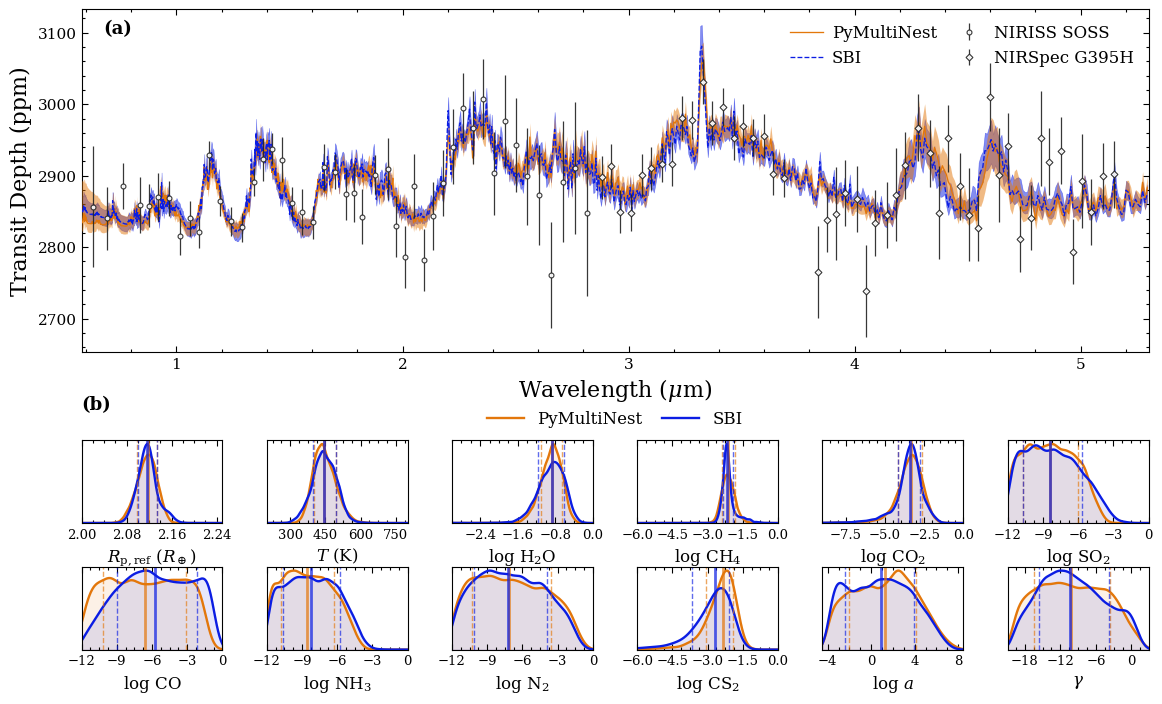

In [12]:
fig, axes, metadata = make_comparison_figure(products, config)
outputs = save_comparison_figure(fig, metadata, config)
plt.show()

if SHOW_VALIDATION_VALUES:
    print(f"Validation values shown in Panel {config.panel_labels['posterior']}:")
    print('  Median posterior offset:', metadata['agreement_metrics']['median_posterior_offset_sigma'])
    print('  Medians within threshold:', metadata['agreement_metrics']['n_medians_within_threshold'])
    print('  Overlapping 68% intervals:', metadata['agreement_metrics']['n_intervals_68_overlap'])
    print('  Mean predictive difference:', metadata['agreement_metrics']['mean_predictive_difference_sigma_data'])

## Output locations

In [13]:
for product, path in outputs.items():
    print(f'{product}: {path}')

pdf: /home/eraul/wisconsin/work/atmosphere_research_2026/POSEIDON/run/POSEIDON_output/TOI-270d/plots/FINESST/figure1_TOI270d_SBI_validation_no_runtime.pdf
metadata: /home/eraul/wisconsin/work/atmosphere_research_2026/POSEIDON/run/POSEIDON_output/TOI-270d/plots/FINESST/figure1_TOI270d_SBI_validation_no_runtime_metadata.json
